In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
BASE_DIR = Path.cwd()
csv_path = BASE_DIR / "../../CSV/landuse_change_concentration_timeseries.csv"

df = pd.read_csv(csv_path)

df = df[df["year"] != 2010]


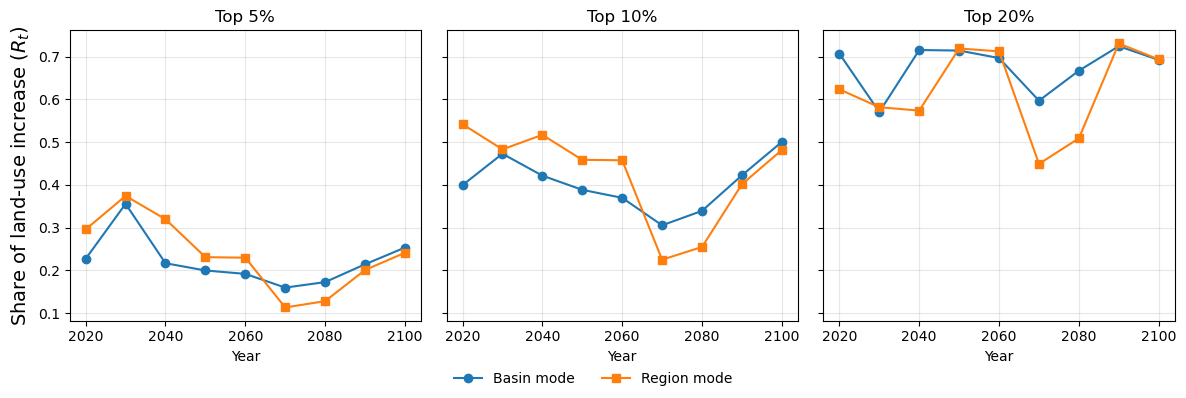

In [2]:

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 4),
    sharey=True
)

top_levels = [
    ("top5", "Top 5%"),
    ("top10", "Top 10%"),
    ("top20", "Top 20%"),
]

for ax, (lvl, title) in zip(axes, top_levels):
    ax.plot(
        df["year"],
        df[f"basin_{lvl}"],
        marker="o",
        label="Basin mode"
    )
    ax.plot(
        df["year"],
        df[f"region_{lvl}"],
        marker="s",
        label="Region mode"
    )

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)

# 统一 y 轴
axes[0].set_ylabel(r"Share of land-use increase ($R_t$)", fontsize=14)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)
plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(
    "../../plot/landuse_change_concentration_timeseries.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()